# Cross-Sectional Strategies

In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt
from   matplotlib.lines import Line2D
from   matplotlib.ticker import FuncFormatter

import statsmodels.api as sm
from   statsmodels.regression.rolling import RollingOLS

In [2]:
repo_path  = os.path.abspath(os.path.join(os.getcwd(), ".."))
data_path  = os.path.join(repo_path, "data")
latex_path = os.path.join(repo_path, "writeup")
pic_path   = os.path.join(latex_path, "pictures")

In [17]:
float_format = "{:,.2f}".format

In [3]:
renamer1_ = {
    "forward_inf" : "5y5y",
    "surprise_inf": "Surprise",
    "out_sample"  : "Out-Sample",
    "in_sample"   : "In-Sample",
    "full_sample" : "Full Sample",
    "train_test"  : "Train/Test",
    "lagged"      : "Lagged",
    "perfect"     : "Perfect",
    "expanding"   : "Expanding",
    "resid"       : "OLS Residuals",
    "zscore"      : "Z-Score",
    "LowerGroup"  : "Long Leg",
    "UpperGroup"  : "Short Leg",
    "spread"      : "Net"}

renamer     = {**renamer1_}
col_orderer = ["Long Leg", "Short Leg", "Net"]

In [4]:
path = r"C:\Users\Diego\Documents\GitHub\CommodityForwardInflation\data\Backtests\CrossectionaLOLSResidual.parquet"
df_raw = (pd
    .read_parquet(path = path, engine = "pyarrow"))

In [5]:
df_net = (df_raw
    .drop(columns = ["security", "sample_group"])
    .groupby(["date", "group", "regression", "country", "signal_name", "target"])
    .agg("mean")
    .reset_index()
    .pivot(index = ["date", "regression", "country", "signal_name", "target"], columns = "group", values = "rtn")
    .assign(spread = lambda x: x.LowerGroup - x.UpperGroup)
    .reset_index())

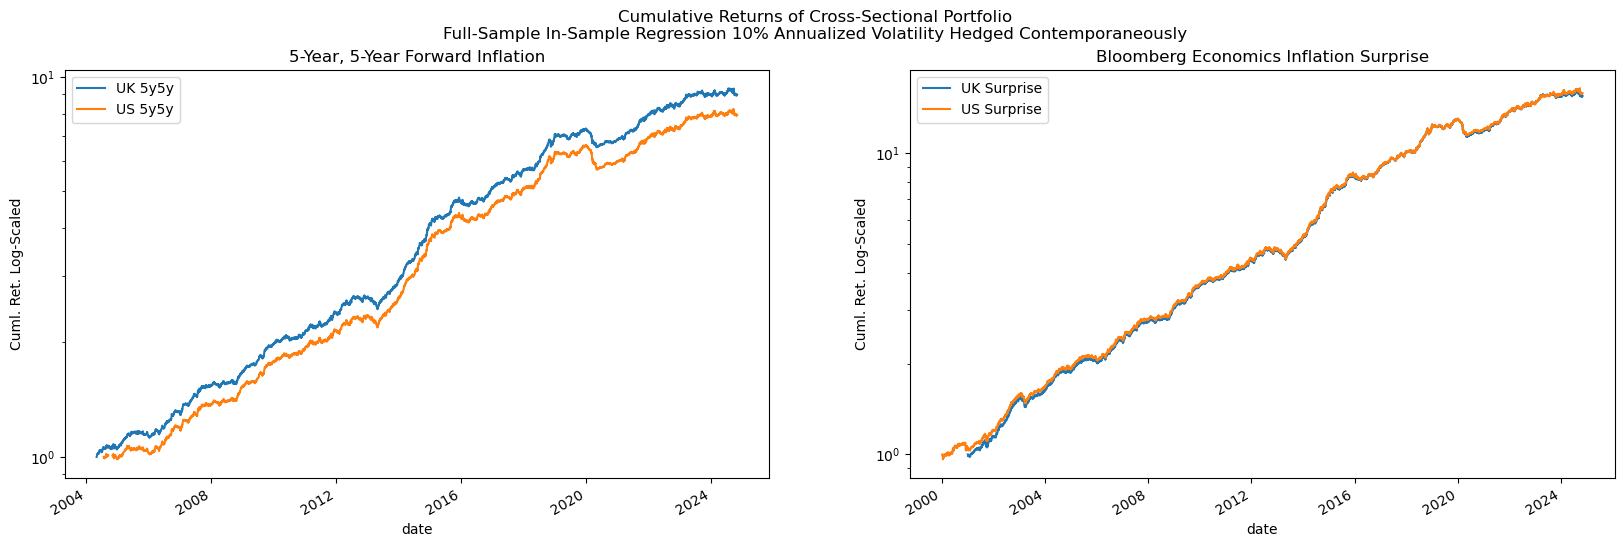

In [15]:
df_tmp_net = df_net.loc[lambda x: (x.regression == "full_sample") & (x.target == "perfect")]
group_vars = df_net.signal_name.drop_duplicates().sort_values().to_list()
fig, axes  = plt.subplots(ncols = len(group_vars), figsize = (20,6))

title_renamer = {
    "forward_inf" : "5-Year, 5-Year Forward Inflation",
    "surprise_inf": "Bloomberg Economics Inflation Surprise"}

for group_var, ax in zip(group_vars, axes.flatten()): 

    (df_tmp_net
        .loc[lambda x: x.signal_name == group_var]
        .replace(renamer)
        .assign(name = lambda x: x.country + " " + x.signal_name)
        .rename(columns = {"name": ""})
        .pivot(index = "date", columns = "", values = "spread")
        .apply(lambda x: np.where(np.abs(x) > 0.1, np.nan, x))
        .apply(lambda x: np.cumprod(1 + x))
        .plot(
            logy   = True,
            ax     = ax,
            title  = title_renamer[group_var],
            ylabel = "Cuml. Ret. Log-Scaled"))

fig.suptitle("Cumulative Returns of Cross-Sectional Portfolio\nFull-Sample In-Sample Regression 10% Annualized Volatility Hedged Contemporaneously\n")
out_path = os.path.join(pic_path, "LSCommodPerformance.jpeg")
fig.savefig(out_path, dpi = 300)
plt.show()

In [20]:
display(df_tmp_net
    .drop(columns = ["target", "regression"])
    .melt(id_vars = ["date", "country", "signal_name"])
    .assign(value = lambda x: np.where(np.abs(x.value) > 0.1, np.nan, x.value))
    .drop(columns = ["date"])
    .groupby(["country", "signal_name", "group"])
    .agg(lambda x: x.mean() / x.std() * np.sqrt(252))
    .reset_index()
    .replace(renamer)
    .pivot(index = ["country", "signal_name"], columns = "group", values = "value")
    .rename(columns = renamer)
    [col_orderer])

group                Long Leg  Short Leg       Net
country signal_name                               
UK      5y5y         0.742897  -0.518701  1.936950
        Surprise     0.823501  -0.526498  2.057879
US      5y5y         0.682677  -0.544545  1.883319
        Surprise     0.884505  -0.417987  1.965067

In [8]:
df_corrs = (df_tmp_net
    .drop(columns = ["regression", "target"])
    .melt(id_vars = ["date", "country", "signal_name"])
    .replace(renamer)
    .assign(name = lambda x: x.country + "\n" + x.signal_name)
    .drop(columns = ["country", "signal_name"])
    .pivot(index = ["date", "group"], columns = "name", values = "value")
    .reset_index()
    .drop(columns = ["date"])
    .groupby("group")
    .agg("corr")
    .reset_index())

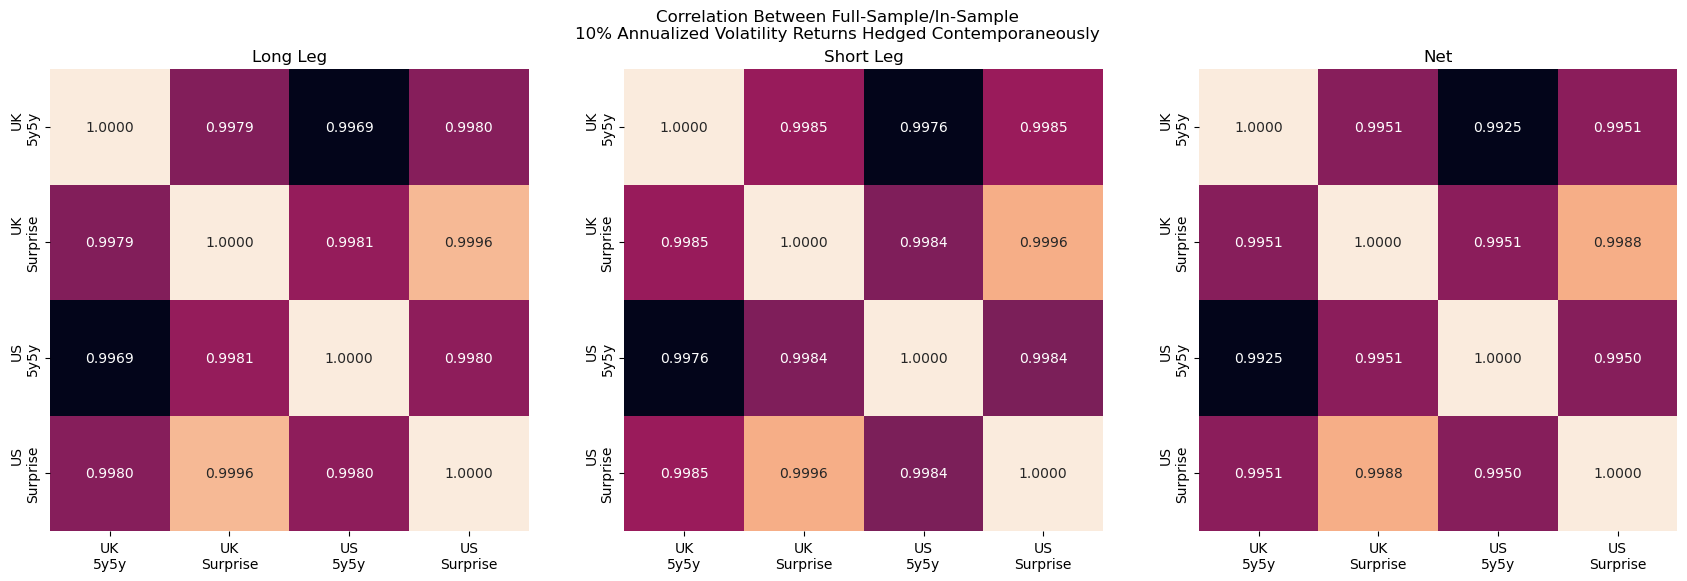

In [9]:
fig, axes  = plt.subplots(ncols = len(col_orderer), figsize = (7 * len(col_orderer), 6))
for group_var, ax in zip(col_orderer, axes.flatten()):

    df_tmp = (df_corrs
        .loc[lambda x: x.group == group_var]
        .drop(columns = ["group"])
        .set_index("name"))

    sns.heatmap(
        ax    = ax,
        data  = df_tmp,
        cbar  = False,
        annot = True,
        fmt   = ".4f")

    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_title(group_var)

fig.suptitle("Correlation Between Full-Sample/In-Sample\n10% Annualized Volatility Returns Hedged Contemporaneously\n")
plt.show()

In [10]:
df_net_sharpe = (df_net
    .melt(id_vars = ["date", "regression", "country", "signal_name", "target"])
    .assign(value = lambda x: np.where(np.abs(x.value) > 0.1, np.nan, x.value))
    .drop(columns = ["date"])
    .groupby(["regression", "country", "signal_name", "target", "group"])
    .agg(lambda x: x.mean() / x.std() * np.sqrt(252))
    .reset_index())

In [23]:
display(df_net_sharpe
    .replace(renamer)
    .rename(columns = {
        "regression" : "Regression",
        "signal_name": "Signal",
        "country"    : "Country",
        "group"      : "Leg",
        "target"     : "Target"})
    .pivot(index = ["Regression", "Signal", "Country"], columns = ["Target", "Leg"], values = "value"))

Target                          Lagged                       Perfect  \
Leg                           Long Leg Short Leg       Net  Long Leg   
Regression  Signal   Country                                           
Expanding   5y5y     UK       0.751021 -0.502033  1.886218  0.730962   
                     US       0.691022 -0.514053  1.817571  0.666275   
            Surprise UK       0.866999 -0.520030  2.091488  0.830126   
                     US       0.893176 -0.425567  1.973998  0.855346   
Full Sample 5y5y     UK       0.764331 -0.505974  1.923700  0.742897   
                     US       0.703902 -0.529083  1.862485  0.682677   
            Surprise UK       0.856439 -0.518155  2.070699  0.823501   
                     US       0.924121 -0.404441  1.983114  0.884505   
Train/Test  5y5y     UK       0.757841 -0.499979  1.904380  0.736715   
                     US       0.706264 -0.531716  1.864051  0.684935   
            Surprise UK       0.853197 -0.514608  2.059733  0.820448   
                     US       0.921480 -0.402004  1.976215  0.882128   

Target                                            
Leg                          Short Leg       Net  
Regression  Signal   Country                      
Expanding   5y5y     UK      -0.511854  1.898083  
                     US      -0.529237  1.831070  
            Surprise UK      -0.535385  2.083605  
                     US      -0.439227  1.959302  
Full Sample 5y5y     UK      -0.518701  1.936950  
                     US      -0.544545  1.883319  
            Surprise UK      -0.526498  2.057879  
                     US      -0.417987  1.965067  
Train/Test  5y5y     UK      -0.512895  1.918238  
                     US      -0.546900  1.881809  
            Surprise UK      -0.523136  2.047449  
                     US      -0.415795  1.958810

In [27]:
display(df_net_sharpe
    .loc[lambda x: x.group == "spread"]
    .drop(columns = ["group"])
    .pivot(index = ["country", "signal_name", "target"], columns = "regression", values = "value")
    .reset_index()
    .melt(id_vars = ["country", "signal_name", "target", "full_sample"])
    .replace(renamer)
    .rename(columns = {
        "country"    : "Country",
        "signal_name": "Signal",
        "regression" : "",
        "target"     : "Target"})
    .assign(spread = lambda x: x.value - x.full_sample)
    .pivot(index = ["Country", "Signal", "Target"], columns = "", values = "spread"))

Expanding  Train/Test
Country Signal   Target                        
UK      5y5y     Lagged   -0.037482   -0.019320
                 Perfect  -0.038867   -0.018712
        Surprise Lagged    0.020789   -0.010966
                 Perfect   0.025727   -0.010430
US      5y5y     Lagged   -0.044914    0.001566
                 Perfect  -0.052249   -0.001510
        Surprise Lagged   -0.009115   -0.006898
                 Perfect  -0.005765   -0.006256

In [29]:
display(df_net_sharpe
    .loc[lambda x: x.group == "spread"]
    .pivot(index = ["regression", "country", "signal_name"], columns = "target", values = "value")
    .assign(spread = lambda x: x.perfect - x.lagged)
    .reset_index()
    .replace(renamer)
    .rename(columns = {
        "country"    : "Country",
        "signal_name": "Signal",
        "regression" : ""})
    .pivot(index = ["Country", "Signal"], columns = "", values = "spread"))

Expanding  Full Sample  Train/Test
Country Signal                                      
UK      5y5y       0.011865     0.013251    0.013858
        Surprise  -0.007883    -0.012821   -0.012285
US      5y5y       0.013499     0.020834    0.017757
        Surprise  -0.014697    -0.018047   -0.017405